

Epoch 1/50

25/25 [==============================] - 1s 11ms/step - loss: 0.1410 - val_loss: 0.0187
Epoch 2/50
25/25 [==============================] - 0s 4ms/step - loss: 0.0058 - val_loss: 0.0010
Epoch 3/50
25/25 [==============================] - 0s 4ms/step - loss: 5.2372e-04 - val_loss: 2.7357e-04
Epoch 4/50
25/25 [==============================] - 0s 4ms/step - loss: 1.6793e-04 - val_loss: 9.9851e-05
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 9.6250e-05 - val_loss: 8.8566e-05
Epoch 6/50
25/25 [==============================] - 0s 3ms/step - loss: 8.9385e-05 - val_loss: 9.3502e-05
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: 8.7249e-05 - val_loss: 8.4174e-05
Epoch 8/50
25/25 [==============================] - 0s 5ms/step - loss: 9.0985e-05 - val_loss: 1.0211e-04
Epoch 9/50
25/25 [==============================] - 0s 4ms/step - loss: 9.5929e-05 - val_loss: 8.6321e-05
Epoch 10/50
25/25 [==============================] - 0s 4m

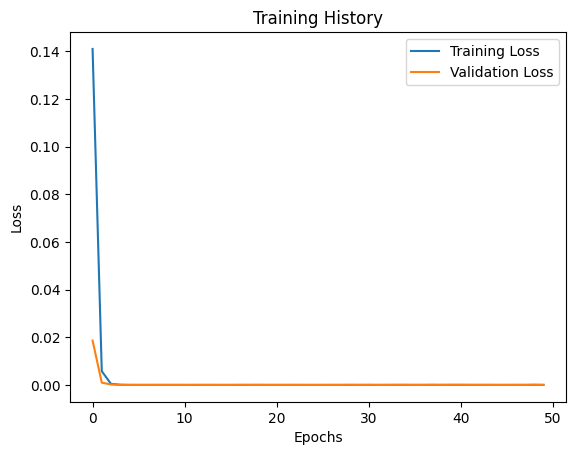

32/32 [==============================] - 0s 2ms/step


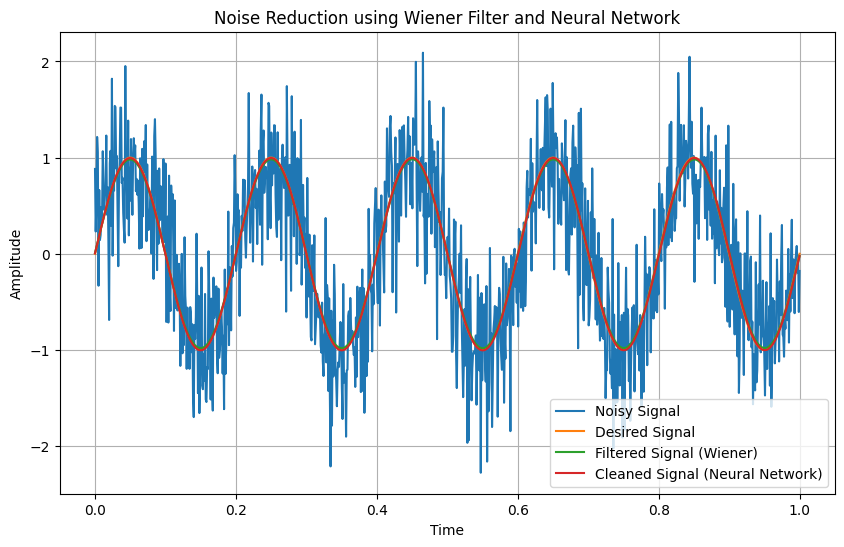

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal, desired_signal, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = desired_signal.reshape(-1, 1)  # Using desired_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(t, cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_dat_file(file_path):
    """
    Load data from a .dat file.

    Parameters:
    file_path (str): The path to the .dat file.

    Returns:
    data (array): The data loaded from the file.
    """
    return np.loadtxt(file_path)

# Load your .dat files
input_signal_dat = load_dat_file(".dat")
desired_signal_dat = load_dat_file("desired_signal.dat")

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal_dat, desired_signal_dat, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = desired_signal_dat.reshape(-1, 1)  # Using desired_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(input_signal_dat, label='Noisy Signal')
plt.plot(desired_signal_dat, label='Desired Signal')
plt.plot(filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

def load_dat_file(file_path,length=None):
    """
    Load data from a .dat file.

    Parameters:
    file_path (str): The path to the .dat file.

    Returns:
    data (array): The data loaded from the file.
    """
    data =  np.loadtxt(file_path, skiprows=1)
    if length is not None:
        return data[:length]
    else:
        return data


# Load your .dat files
noisy_signal_dat = load_dat_file("fan.dat")
clear_signal_dat = load_dat_file("song.dat",len(noisy_signal_dat))

# Combine clear and noisy signals
input_signal_dat = clear_signal_dat + noisy_signal_dat

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal_dat, clear_signal_dat, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = clear_signal_dat.reshape(-1, 1)  # Using clear_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(noisy_signal_dat, label='Noisy Signal')
plt.plot(clear_signal_dat, label='Clear Signal')
plt.plot(filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()




Epoch 1/50

73666/73666 [==============================] - 101s 1ms/step - loss: 0.0099 - val_loss: 1.3809e-05
Epoch 2/50
73666/73666 [==============================] - 109s 1ms/step - loss: 9.3939e-04 - val_loss: 1.4374e-05
Epoch 3/50
73666/73666 [==============================] - 120s 2ms/step - loss: 6.6958e-04 - val_loss: 1.4431e-05
Epoch 4/50
73666/73666 [==============================] - 106s 1ms/step - loss: 6.2592e-04 - val_loss: 1.4582e-05
Epoch 5/50
73666/73666 [==============================] - 104s 1ms/step - loss: 4.8581e-04 - val_loss: 2.2499e-05
Epoch 6/50
73666/73666 [==============================] - 165s 2ms/step - loss: 4.4777e-04 - val_loss: 1.8152e-05
Epoch 7/50
73666/73666 [==============================] - 169s 2ms/step - loss: 3.7118e-04 - val_loss: 1.3707e-05
Epoch 8/50
73666/73666 [==============================] - 155s 2ms/step - loss: 3.4481e-04 - val_loss: 3.9784e-05
Epoch 9/50
73666/73666 [==============================] - 153s 2ms/step - loss: 2.6634e-0

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

def load_dat_file(file_path,length=None):
    """
    Load data from a .dat file.

    Parameters:
    file_path (str): The path to the .dat file.

    Returns:
    data (array): The data loaded from the file.
    """
    data =  np.loadtxt(file_path, skiprows=1)
    if length is not None:
        return data[:length]
    else:
        return data


# Load your .dat files
noisy_signal_dat = load_dat_file("fan.dat")
clear_signal_dat = load_dat_file("song.dat",len(noisy_signal_dat))

# Combine clear and noisy signals
input_signal_dat = clear_signal_dat + noisy_signal_dat

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal_dat, clear_signal_dat, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = clear_signal_dat.reshape(-1, 1)  # Using clear_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=32)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(noisy_signal_dat, label='Noisy Signal')
plt.plot(clear_signal_dat, label='Clear Signal')
plt.plot(filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()





Epoch 1/50

25/25 [==============================] - 1s 9ms/step - loss: 0.1353 - val_loss: 0.0160
Epoch 2/50
25/25 [==============================] - 0s 4ms/step - loss: 0.0057 - val_loss: 9.8008e-04
Epoch 3/50
25/25 [==============================] - 0s 4ms/step - loss: 5.5583e-04 - val_loss: 2.6448e-04
Epoch 4/50
25/25 [==============================] - 0s 4ms/step - loss: 1.4608e-04 - val_loss: 9.5572e-05
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 8.7271e-05 - val_loss: 8.4202e-05
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 8.3389e-05 - val_loss: 8.2128e-05
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: 8.4249e-05 - val_loss: 8.4516e-05
Epoch 8/50
25/25 [==============================] - 0s 4ms/step - loss: 8.7158e-05 - val_loss: 8.8627e-05
Epoch 9/50
25/25 [==============================] - 0s 5ms/step - loss: 8.7130e-05 - val_loss: 9.3351e-05
Epoch 10/50
25/25 [==============================] - 0

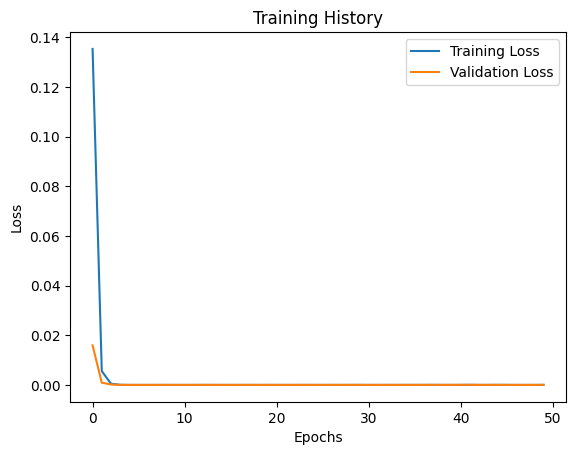

32/32 [==============================] - 0s 2ms/step


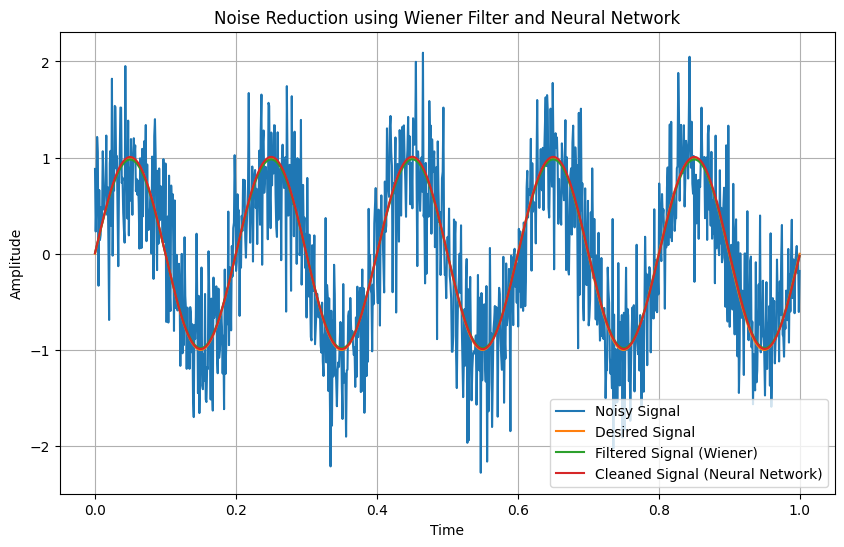

Amplitude Reduction Percentage: 54.19166653988516 %
Response Time (seconds): 0.01001001001001001
Accuracy: -100.04378940646129 %


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal, desired_signal, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = desired_signal.reshape(-1, 1)  # Using desired_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(t, cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(cleaned_signal_neural_network) - np.min(cleaned_signal_neural_network)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Calculate mean squared error (MSE)
mse = np.mean((cleaned_signal_neural_network - desired_signal) ** 2)

# Calculate accuracy in percentage
accuracy = (1 - (mse / np.mean(desired_signal ** 2))) * 100

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy, "%")
